In [1]:
import numpy as np
import matplotlib.pylab as plt
import pickle
from scipy.integrate import simpson

In [48]:
#Decreasing force
filename = 'Block10_CGT.pkl'

with open(filename,'rb') as file:
    CGT01 = pickle.load(file)
    CGT03 = pickle.load(file)

In [59]:
#Method
#Bond length
b = 1

#Get segmental end-to-end distance
def segRee(D, Atom_Type):
    #Ree parameters
    M = 100; N = 100
    Ncols = 9
    Nf = D.shape[0]
    Mseg = N//10*M
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,10,Ncols) #exclude first frame

    Xseg = D[:,:,:,3:6]

    if(Atom_Type == 'Hydrophilic'):
        # Get just the odd segments (hydrophilic segments)
        Xhp =  Xseg[:,1::2,:,:]
    elif(Atom_Type == 'Hydrophobic'):
        # Get just the even segments (hydrophobic segments)
        Xhp =  Xseg[:,0::2,:,:]
    
    # End-to-End vectors of the segments
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)
    return Rhp

#Calculate correlation time
def ComputeTauC(mRee):
    dRee = mRee - mRee.mean()
    result = np.correlate(dRee, dRee, mode = 'full')
    result = result[result.size // 2:] # Keep the positive lags
    acf = result / result[0] #Normalized autocorrelation
    
    #Apply numerical integration
    positive_acf = acf[acf > 0]  # Ignore negative part to avoid integration errors
    tau_c = simpson(positive_acf, dx=1) #Correlation time
    return tau_c

In [4]:
#Define bin size and domain of order parameter
bin = 100
domain = [1.5, 9.11]
rang = np.linspace(domain[0], domain[1], bin + 1)
xh = (rang[:-1]+rang[1:])/2

In [5]:
cTau = np.array([]) #Collect correlation time for each simulation
samples = []
for i in range(3, 14):
    D = segRee(CGT01.ParsedRee[i], 'Hydrophobic')
    samples.append(D.flatten())
    
    #Get correlation time
    mRee = np.mean(D, axis = 1)
    cTau = np.append(cTau, ComputeTauC(mRee))

In [6]:
#Umbrella Sampling
paths = [
    '../block10/T0.1/Success :)/R=6/dump.rc2.5N100Tp1',
    '../block10/T0.1/Success :)/R=8/dump.rc2.5N100Tp1',
    '../block10/T0.1/Success :)/R=8.5/dump.rc2.5N100Tp1',
    ]

R = [6, 8, 8.5]
k = [2, 1, 2]
i = 0

F_umbrella = np.empty((0,bin))

for path in paths:
    
    with open(path, 'r') as file:
        
        LINES = file.readlines()
        
        Nf = len(LINES) // (1009)

        file.seek(0) # go back to start of file

        all_frames=[]

        while True:
            # Skip the non-numeric header lines (assumed to be 9 lines)
            for _ in range(9):
                line = file.readline()
                if not line:
                    break  # End of file
            else:
                # Read the next block of data
                frame_data = np.loadtxt(file, max_rows=1000)
                all_frames.append(frame_data)
                continue
            break  # Exit the loop if EOF

    # Combine all frames into a single numpy array
    D = np.vstack(all_frames).reshape(Nf,1000,9)

    #Sort each frame by atom type
    for f in range(Nf):
        ids = D[f,:,0]
        key = np.argsort(ids)
        D[f,:,:] = D[f,key,:]

    Nf = D.shape[0]

    #Extract all atoms that are type 3
    Type2 = D[D[:,:,2] == 2]
    Type2 = Type2.reshape(Nf, 100, 9)

    #Extract all atoms that are type 4
    Type3 = D[D[:,:,2] == 3]
    Type3 = Type3.reshape(Nf, 100, 9)

    #Extract Position vector
    Type2 = Type2[:,:,3:6]
    Type3 = Type3[:,:,3:6]

    dX = Type2-Type3
    Ree = np.linalg.norm(dX, axis = 2)
    Ree = Ree[10:,:] #Assume equilibrium after this
    samples.append(Ree.flatten())
    
    #Get correlation time
    mRee = np.mean(Ree, axis = 1)
    cTau = np.append(cTau, ComputeTauC(mRee))

/tmp/ipykernel_919546/3049945129.py:8: RuntimeWarning: divide by zero encountered in log
  F = -0.1*np.log(prob)+f*xh
/tmp/ipykernel_919546/3049945129.py:15: RuntimeWarning: divide by zero encountered in log
  F = -0.1*np.log(prob)-k[i]*(xh-R[i])**2


Text(0.5, 1.0, 'Free Energy, Block 10, T = 0.1')

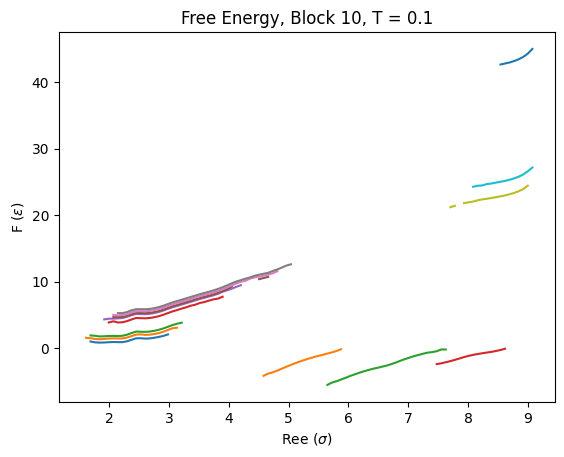

In [7]:
#Find simulations with phase coexistence
Hphobic = np.empty((0,bin))

for i in range(11):
    f = CGT01.f[i+3]
    D = samples[i]
    prob = np.histogram(D,bins=rang)[0]
    F = -0.1*np.log(prob)+f*xh
    plt.plot(xh, F)
    Hphobic = np.append(Hphobic, [F], axis = 0)

for i in range(3):
    D = samples[i+11]
    prob = np.histogram(D,bins=rang)[0]
    F = -0.1*np.log(prob)-k[i]*(xh-R[i])**2
    plt.plot(xh, F)
    Hphobic = np.append(Hphobic, [F], axis = 0)

plt.xlabel("Ree ($\sigma$)")
plt.ylabel("F ($\epsilon$)")
plt.title('Free Energy, Block 10, T = 0.1')

## Use Pymbar

In [8]:
# #Initialize variables for MBAR object
# beta = 1 / 0.1 #beta = 1/kT
# N_k = np.empty((0)) #Number of samples per umbrella simulation
# x_n = np.array([]) #Concatenate all observations

# for s in samples:
#     x_n = np.append(x_n, s)
#     N_k = np.append(N_k, s.shape[0])

# f = CGT01.f[3:]

# #Build reduced potential matrix
# u_kn = np.empty((0, x_n.shape[0]))

# prob = np.histogram(x_n,bins=rang)[0]
# bin_index = np.searchsorted(rang, x_n, side='left') - 1

# for i in range(11):
#     F = beta*(-f[i]*xh)
#     u = F[bin_index]
#     u_kn = np.append(u_kn, [u], axis = 0)

# for i in range(3):
#     F = beta*k[i]*(xh-R[i])**2
#     u = F[bin_index]
#     u_kn = np.append(u_kn, [u], axis = 0)

In [9]:
# #Build MBAR object
# from pymbar import MBAR

# mbar = MBAR(u_kn, N_k)
# results = mbar.compute_free_energy_differences()

In [10]:
# dist = results['Delta_f']
# offset = []
# for i in range(14):
#     offset.append(dist[0, i])

# offset

In [11]:
# for i in range(11):
#     D = samples[i]
#     prob = np.histogram(D,bins=rang)[0]
#     F = -0.1*np.log(prob)+f[i]*xh-offset[i]
#     plt.plot(xh, F)

# c = 11
# for i in range(3):
#     D = samples[c]
#     prob = np.histogram(D,bins=rang)[0]
#     F = -0.1*np.log(prob)-k[i]*(xh-R[i])**2-offset[c]
#     plt.plot(xh, F)
#     c+=1

## Code MBAR

In [ ]:
# #Bia potential at each simulation
# f = CGT01.f[3:]
# eta = np.empty((0, bin))
# for force in f:
#     eta = np.append(eta, [-force*xh], axis = 0)

# #Umbrella simulation parameters
# R = [6, 8, 8.5]
# k = [2, 1, 2]
# for i in range(3):
#     eta = np.append(eta, [k[i]*(xh-R[i])**2], axis = 0)

In [55]:
# #MBAR

# beta = 1 / 0.1 #beta = 1/kT
# N_k = np.empty((0)) #Number of samples per umbrella simulation
# x_n = np.array([]) #Concatenate all observations

# for s in samples:
#     x_n = np.append(x_n, s)
#     N_k = np.append(N_k, s.shape[0])
    
# c_tot = np.histogram(x_n,bins=rang)[0] #Number of histogram counts at each Ree bin

# #Calculate disretized free energy for all bins
# def ComputeF(A_j):
#     sum = np.zeros(bin)
#     for j in range(14):
#         sum = sum + N_k[j]*np.exp(-beta*(eta[j]-A_j[j]))
#     F = (np.log(c_tot)-np.log(sum))/beta
#     return F

# def ComputeA_j(F):
#     #Calculate A_j using F
#     A_j = np.empty(0)
#     for j in range(14):
#         #Sum over not inf values
#         power = -beta*(F+eta[j])
#         arr = np.exp(power.astype(np.float128))
#         mask = ~np.isinf(arr)
#         sum = np.sum(arr[mask])
#         A_j = np.append(A_j, -np.log(sum)/beta)
#     return A_j

# #Initial guess for A_j
# A_j_prev = np.zeros(14)
# for i in range(10000):
#     F_prev = ComputeF(A_j_prev)
#     A_j_prev = ComputeA_j(F_prev)
#     F_new = ComputeF(A_j_prev)
#     A_j_new = ComputeA_j(F_new)
#     diff = np.abs(A_j_prev-A_j_new)
#     if diff.max() < 1:
#         print(i)
#         break
#     A_j_prev = A_j_new

In [56]:
# plt.plot(xh, -F_prev)
# plt.plot(xh, -F_new+85)

In [15]:
# offset = A_j_new-A_j_new[-4]

## Ferrenberg and Swendsen

In [19]:
#Collect all the variables
g_n = 1+2*cTau

#Number of obsevations in each bin of each umbrella simulation
N_n = np.empty((0, bin))
for s in samples:
    N = np.histogram(s,bins=rang)[0]
    N_n = np.append(N_n, [N], axis = 0)

#Number of observations in each simulation
n_m = np.empty((0)) #Number of samples per umbrella simulation
for s in samples:
    n_m = np.append(n_m, s.shape[0])

#Bia potential at each simulation
f = CGT01.f[3:]
eta = np.empty((0, bin))
for force in f:
    eta = np.append(eta, [-force*xh], axis = 0)

#Umbrella simulation parameters
R = [6, 8, 8.5]
k = [2, 1, 2]
for i in range(3):
    eta = np.append(eta, [k[i]*(xh-R[i])**2], axis = 0)

#Energy scaling
beta = -1/0.1

In [24]:
#Mbar Method

power = beta*eta
blzmF = np.exp(power.astype(np.float128))
numerator = 1/g_n @ N_n
def iterate(f_n):
    exponent = beta*(eta-f_n[:, np.newaxis])
    denominator = n_m*1/g_n@np.exp(exponent.astype(np.float128))
    P = (numerator / denominator)[np.newaxis, :]*blzmF
    sum = np.sum(P, axis = 1)
    f_n = np.log(sum)/beta
    return f_n

In [31]:
#Start by assuming free energy difference is 0
f_n = np.zeros(14)

for i in range(10000):
    f_n_new = iterate(f_n)
    diff = np.abs(f_n-f_n_new)
    if diff.max() < 0.000001:
        print(i)
        break
    f_n = f_n_new

5215


In [32]:
f_n = f_n-f_n[-4]

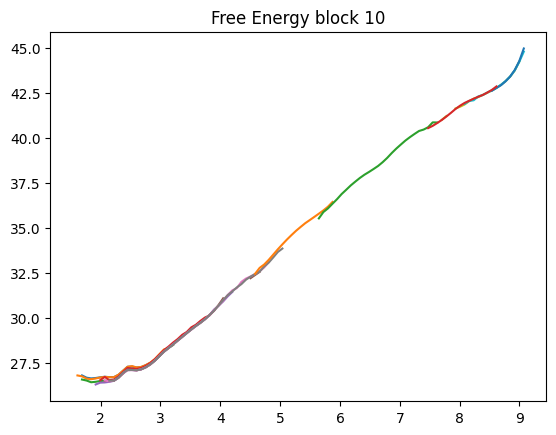

In [47]:
f_n = f_n-f_n[-4] #Reference with respect to the extended coil
for i in range(14):
    plt.plot(xh, Hphobic[i]+f_n[i])

plt.title('Free Energy block 10')
F_landscape = Hphobic + f_n[:, np.newaxis]
#Take the mean
F_landscape = np.where(np.isinf(F_landscape), np.nan, F_landscape)
F_landscape = np.nanmean(F_landscape, axis = 0)

### T = 0.3

In [57]:
#Define bin size and domain of order parameter
bin = 100
domain = [0.98, 9.05]
rang = np.linspace(domain[0], domain[1], bin + 1)
xh = (rang[:-1]+rang[1:])/2

In [60]:
cTau = np.array([]) #Collect correlation time for each simulation
samples = []
for i in range(3, 12):
    D = segRee(CGT03.ParsedRee[i], 'Hydrophobic')
    samples.append(D.flatten())
    
    #Get correlation time
    mRee = np.mean(D, axis = 1)
    cTau = np.append(cTau, ComputeTauC(mRee))

/tmp/ipykernel_919546/3366848378.py:8: RuntimeWarning: divide by zero encountered in log
  F = -0.3*np.log(prob)+f*xh


Text(0.5, 1.0, 'Free Energy, Block 10, T = 0.3')

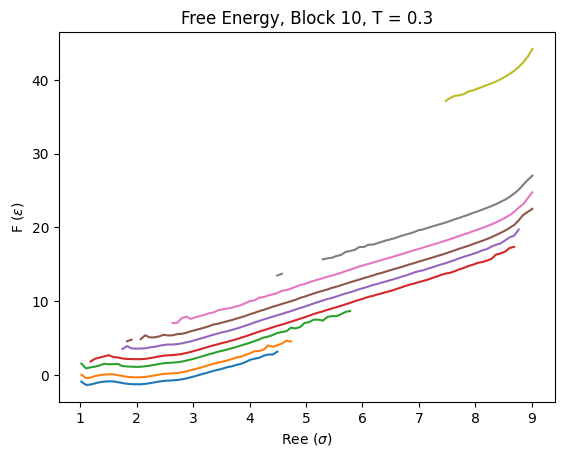

In [61]:
#Find simulations with phase coexistence
Hphobic = np.empty((0,bin))

for i in range(3, 12):
    f = CGT03.f[i]
    D = samples[i-3]
    prob = np.histogram(D,bins=rang)[0]
    F = -0.3*np.log(prob)+f*xh
    plt.plot(xh, F)
    Hphobic = np.append(Hphobic, [F], axis = 0)

plt.xlabel("Ree ($\sigma$)")
plt.ylabel("F ($\epsilon$)")
plt.title('Free Energy, Block 10, T = 0.3')

In [62]:
#Collect all the variables
g_n = 1+2*cTau

#Number of obsevations in each bin of each umbrella simulation
N_n = np.empty((0, bin))
for s in samples:
    N_data = np.histogram(s,bins=rang)[0]
    N_n = np.append(N_n, [N_data], axis = 0)

#Number of observations in each simulation
n_m = np.empty((0)) #Number of samples per umbrella simulation
for s in samples:
    n_m = np.append(n_m, s.shape[0])

#Bia potential at each simulation
f = CGT03.f[3:]
eta = np.empty((0, bin))
for force in f:
    eta = np.append(eta, [-force*xh], axis = 0)

#Energy scaling
beta = -1/0.3

In [63]:
#Mbar Method
power = beta*eta
blzmF = np.exp(power.astype(np.float128))
numerator = 1/g_n @ N_n
def iterate(f_n):
    exponent = beta*(eta-f_n[:, np.newaxis])
    denominator = n_m*1/g_n@np.exp(exponent.astype(np.float128))
    P = (numerator / denominator)[np.newaxis, :]*blzmF
    sum = np.sum(P, axis = 1)
    f_n = np.log(sum)/beta
    return f_n

In [64]:
#Start by assuming free energy difference is 0
f_n = np.zeros(9)

for i in range(100000):
    f_n_new = iterate(f_n)
    diff = np.abs(f_n-f_n_new)
    if diff.max() < 1e-18:
        print(i)
        break
    f_n = f_n_new

f_n = f_n-f_n[0] #Reference with respect to the extended coil

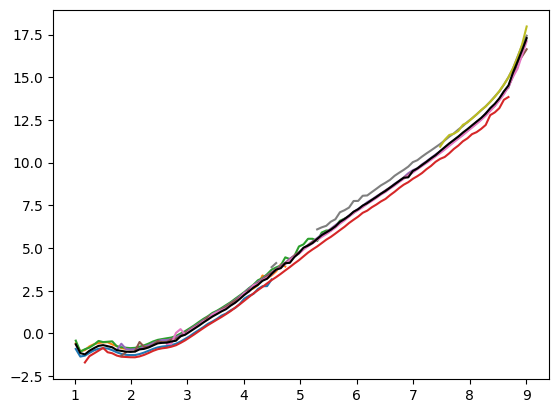

In [65]:
Hphobic = Hphobic+f_n[:, np.newaxis]
for i in range(9):
    plt.plot(xh, Hphobic[i])

#Take the mean
Hphobic = np.where(np.isinf(Hphobic), np.nan, Hphobic)
Hphobic = np.nanmean(Hphobic, axis = 0)
plt.plot(xh, Hphobic, color = 'k')